In [13]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.transform import resize, rotate
import glob
import os

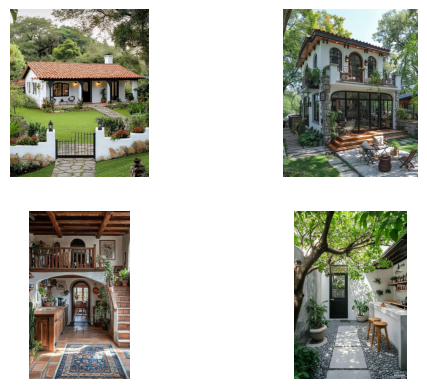

In [7]:
# 1. Tiến hành load toàn bộ ảnh trong 1 thư mục từ drive lên google colab/ 1 thư mục từ máy tính lên Jupyter
file = '/content/sample_data/pictures/*'
images = glob.glob(file)
img = [cv2.imread(f) for f in images]
for i, im in enumerate(img):
  a = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
  plt.subplot(2, 2, i+1)
  plt.imshow(a)
  plt.axis('off')
plt.show()

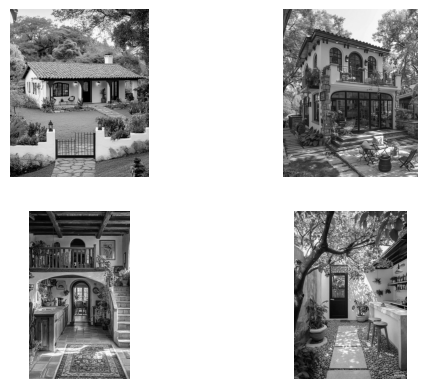

In [10]:
# 2. Đọc từng ảnh trong tập thư mục này, chuyển từng ảnh qua ảnh xám.
file = '/content/sample_data/pictures/*'
images = glob.glob(file)
img = [cv2.imread(f, 0) for f in images]
for i, im in enumerate(img):
  a = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
  plt.subplot(2, 2, i+1)
  plt.imshow(a)
  plt.axis('off')
plt.show()

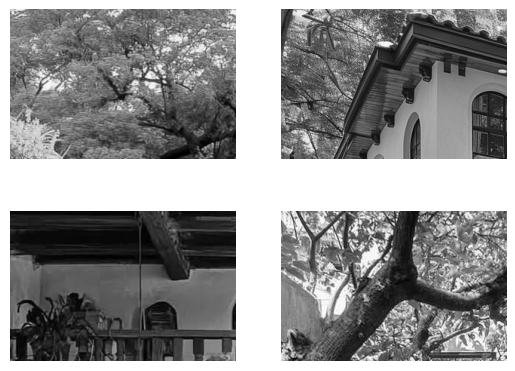

In [11]:
# 3. Cắt tất cả các hình về chung 1 kích thước.
def crop(hinh, x, y, h, w):
  return hinh[y:y+h, :x+w]
img = [cv2.imread(f, 0) for f in images]
for i, im in enumerate(img):
  a = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
  i_crop = crop(a, 100, 100, 200, 200)
  plt.subplot(2, 2, i+1)
  plt.imshow(i_crop)
  plt.axis('off')
plt.show()

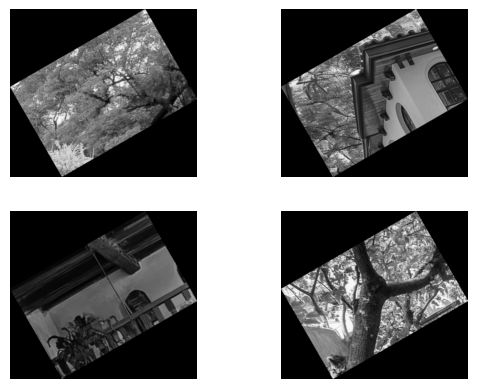

In [27]:
# 4. Xoay các ảnh 1 góc 30 độ.
img = [cv2.imread(f, 0) for f in images]
for i, im in enumerate(img):
  a = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
  i_crop = crop(a, 100, 100, 200, 200)
  i_rotate = rotate(i_crop, 30, resize=True)
  plt.subplot(2, 2, i+1)
  plt.imshow(i_rotate)
  plt.axis('off')
plt.show()

In [53]:
# 5. lưu ảnh đã xoay vào thư mục
import cv2
import os
import matplotlib.pyplot as plt
from skimage.transform import rotate

output_dir = "/content/sample_data/output"

imgs = [cv2.imread(f, 0) for f in images]

for i, im in enumerate(imgs):
    i_crop = im[100:200, 100:200]
    i_rotate = rotate(i_crop, 30, resize=True)
    img_uint8 = (i_rotate * 255).astype("uint8")
    # plt.subplot(2, 2, i+1)
    # plt.imshow(img_uint8, cmap="gray")
    # plt.axis('off')
    save_path = os.path.join(output_dir, f"output_{i+1}.png")
    cv2.imwrite(save_path, img_uint8)
# plt.show()


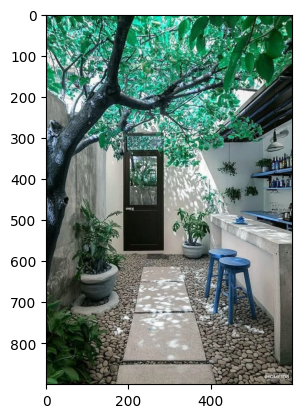

ảnh không vuông


In [65]:
# 6. Đọc 1 ảnh vuông.
def is_square(img):
    h, w = img.shape[:2]
    return h == w
img = cv2.imread('/content/sample_data/pictures/1.jpg')
plt.imshow(img)
plt.show()
if is_square(img):
    print("ảnh là hình vuông")
else:
    print("ảnh không vuông")


In [32]:
# 7. Cài đặt hàm thực hiện chức năng từ hình ảnh đầu vào tiến hành cắt hình ảnh cắt hình ảnh theo kích thước 50*50, sau đó xoá kênh màu Red ở mỗi hình. Hiển thị các hình ảnh mới.
def ex7(hinh):
    img = cv2.imread(hinh)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    H, W, _ = img.shape
    size = 50
    imgs_crop = []
    for y in range(0, H, size):
        for x in range(0, W, size):
            if y+size <= H and x+size <= W:
                c = crop(img, x, y, size, size).copy()
                c[:, :, 0] = 0   # bỏ kênh màu đỏ
                imgs_crop.append(c)

    cols = 5
    rows = (len(imgs_crop) + cols - 1) // cols
    plt.figure(figsize=(15, 3*rows))
    for i, c in enumerate(imgs_crop):
        plt.subplot(rows, cols, i+1)
        plt.imshow(c)
        plt.axis("off")
    plt.show()
ex7('/content/sample_data/pictures/1.jpg')

Output hidden; open in https://colab.research.google.com to view.

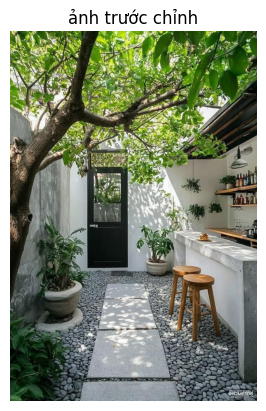

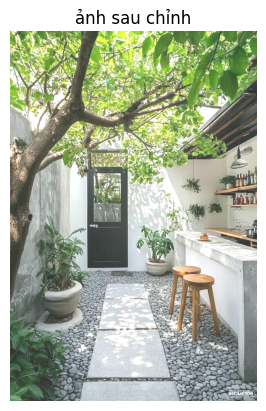

In [46]:
# 8. Cài đặt hàm điều chỉnh mức sáng của 1 ảnh đầu vào.
import cv2
import matplotlib.pyplot as plt

def dieuchinh(hinh_path):
    hinh = cv2.imread(hinh_path)
    n = cv2.convertScaleAbs(hinh, alpha=1, beta=50)
    return n

new_img = dieuchinh('/content/sample_data/pictures/1.jpg')
hinh = cv2.imread('/content/sample_data/pictures/1.jpg')
plt.imshow(cv2.cvtColor(hinh, cv2.COLOR_BGR2RGB))
plt.title("ảnh trước chỉnh")
plt.axis('off')
plt.show()
plt.imshow(cv2.cvtColor(new_img, cv2.COLOR_BGR2RGB))
plt.title("ảnh sau chỉnh")
plt.axis('off')
plt.show()

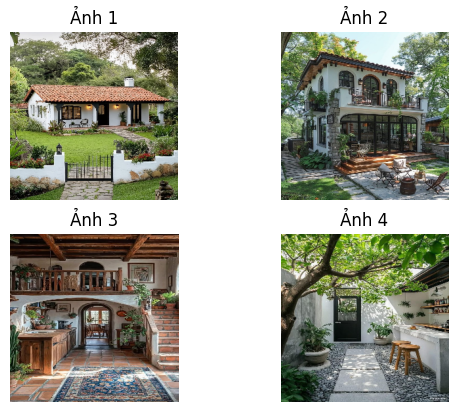

In [52]:
# 9. Cài đặt hàm hiệu chỉnh kích thước của toàn bộ tập ảnh đầu vào thành 256*256.

image_paths = glob.glob("/content/sample_data/pictures/*.*")
image_list = [cv2.imread(path) for path in image_paths]
output_dir = '/content/sample_data/img256'
def resize_all(image_list, size=(256, 256)):
    return [cv2.resize(img, size) for img in image_list]

resized_images = resize_all(image_list, size=(256, 256))
for i, img in enumerate(resized_images):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # 10. lưu vào thư mục mới
    save_path = os.path.join(output_dir, f"img_{i+1}.png")
    cv2.imwrite(save_path, img_rgb)
    plt.subplot(2, 2, i+1)
    plt.imshow(img_rgb)
    plt.title(f"Ảnh {i+1}")
    plt.axis("off")
plt.show()

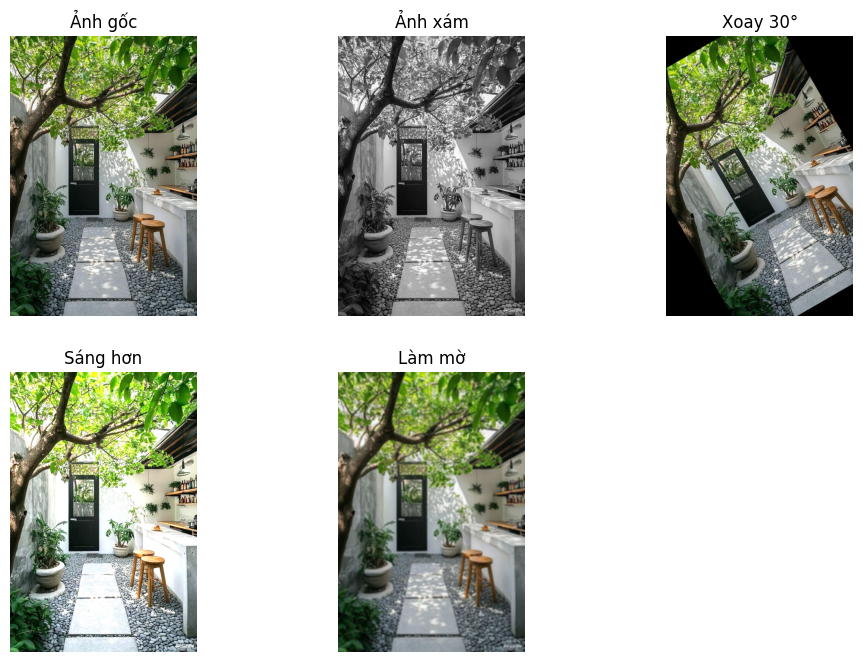

In [55]:
# 11. Làm quen với PIL cho: load ảnh, tạo ảnh xám, xoay ảnh, thay đổi độ sáng, làm mờ.
from PIL import Image, ImageEnhance, ImageFilter
import matplotlib.pyplot as plt

# 1. Load ảnh
img = Image.open("/content/sample_data/pictures/1.jpg")

# 2. Chuyển sang ảnh xám
gray_img = img.convert("L")

# 3. Xoay ảnh (30 độ)
rotated_img = img.rotate(30)

# 4. Thay đổi độ sáng
enhancer = ImageEnhance.Brightness(img)
bright_img = enhancer.enhance(1.5)

# 5. Làm mờ ảnh
blur_img = img.filter(ImageFilter.BLUR)

# Hiển thị kết quả
plt.figure(figsize=(12, 8))

plt.subplot(2,3,1)
plt.imshow(img)
plt.title("Ảnh gốc")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(gray_img, cmap="gray")
plt.title("Ảnh xám")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(rotated_img)
plt.title("Xoay 30°")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(bright_img)
plt.title("Sáng hơn")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(blur_img)
plt.title("Làm mờ")
plt.axis("off")

plt.show()
